
# Verified Badge Detector (Heuristic + Optional Templates)

This notebook detects a **verified badge** (blue circle with a white check ✓) in social-media screenshots using:

1. **Heuristics** (color + shape + check-geometry) — works without any templates.
2. **Optional Template Matching** — provide one or more badge crops for better robustness (dark mode, grayscale variants, etc.).

---


## 1) Install dependencies

In [2]:

!pip install opencv-python numpy pillow matplotlib


  Obtaining dependency information for opencv-python from https://files.pythonhosted.org/packages/fa/80/eb88edc2e2b11cd2dd2e56f1c80b5784d11d6e6b7f04a1145df64df40065/opencv_python-4.12.0.88-cp37-abi3-win_amd64.whl.metadata
  Obtaining dependency information for matplotlib from https://files.pythonhosted.org/packages/33/cd/b145f9797126f3f809d177ca378de57c45413c5099c5990de2658760594a/matplotlib-3.10.7-cp311-cp311-win_amd64.whl.metadata
  Obtaining dependency information for contourpy>=1.0.1 from https://files.pythonhosted.org/packages/98/4b/9bd370b004b5c9d8045c6c33cf65bae018b27aca550a3f657cdc99acdbd8/contourpy-1.3.3-cp311-cp311-win_amd64.whl.metadata
  Obtaining dependency information for cycler>=0.10 from https://files.pythonhosted.org/packages/e7/05/c19819d5e3d95294a6f5947fb9b9629efb316b96de511b418c53d245aae6/cycler-0.12.1-py3-none-any.whl.metadata
  Obtaining dependency information for fonttools>=4.22.0 from https://files.pythonhosted.org/packages/bb/78/0e1a6d22b427579ea5c8273e1c07def2


[notice] A new release of pip is available: 23.2.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


## 2) Imports and utilities

In [3]:

import cv2
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from pathlib import Path
from typing import List, Tuple, Optional

def load_image(path: str) -> np.ndarray:
    """Load image as BGR (OpenCV convention)."""
    img = np.array(Image.open(path).convert("RGB"))
    return cv2.cvtColor(img, cv2.COLOR_RGB2BGR)

def show_bgr(bgr, title=None):
    rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(8, 6))
    if title: plt.title(title)
    plt.imshow(rgb)
    plt.axis("off")
    plt.show()


## 3) Core helpers (NMS / IoU)

In [4]:

def _iou(a: np.ndarray, bs: np.ndarray) -> np.ndarray:
    ax1, ay1, ax2, ay2 = a
    bx1 = bs[:, 0]; by1 = bs[:, 1]; bx2 = bs[:, 2]; by2 = bs[:, 3]
    inter_x1 = np.maximum(ax1, bx1)
    inter_y1 = np.maximum(ay1, by1)
    inter_x2 = np.minimum(ax2, bx2)
    inter_y2 = np.minimum(ay2, by2)
    inter_w = np.maximum(0, inter_x2 - inter_x1 + 1)
    inter_h = np.maximum(0, inter_y2 - inter_y1 + 1)
    inter = inter_w * inter_h
    a_area = (ax2 - ax1 + 1) * (ay2 - ay1 + 1)
    b_area = (bx2 - bx1 + 1) * (by2 - by1 + 1)
    return inter / (a_area + b_area - inter + 1e-9)

def nms(boxes, scores, iou_thr=0.3):
    if len(boxes) == 0:
        return [], []
    boxes_np = np.array(boxes, dtype=np.float32)
    scores_np = np.array(scores, dtype=np.float32)
    idxs = scores_np.argsort()[::-1]
    picks = []
    while len(idxs) > 0:
        i = idxs[0]
        picks.append(i)
        if len(idxs) == 1:
            break
        iou = _iou(boxes_np[i], boxes_np[idxs[1:]])
        idxs = idxs[1:][iou < iou_thr]
    return [boxes[p] for p in picks], [scores[p] for p in picks]


## 4) Heuristic detection — blue badge candidates

In [5]:

def find_blue_badge_candidates(bgr, min_diam_px=16, max_diam_px=None):
    """Find blue-ish near-circular blobs (typical verified badge background)."""
    if max_diam_px is None:
        max_diam_px = int(max(bgr.shape[:2]) * 0.09)
    hsv = cv2.cvtColor(bgr, cv2.COLOR_BGR2HSV)

    # Tolerant blue ranges; adjust if needed
    ranges = [((100, 70, 40), (130, 255, 255)), ((90, 60, 40), (140, 255, 255))]
    mask = None
    for low, high in ranges:
        cur = cv2.inRange(hsv, np.array(low), np.array(high))
        mask = cur if mask is None else cv2.bitwise_or(mask, cur)

    kernel = np.ones((3,3), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel, iterations=2)
    mask = cv2.dilate(mask, kernel, iterations=1)

    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    boxes = []
    for cnt in contours:
        area = cv2.contourArea(cnt)
        if area < 20:
            continue
        x, y, w, h = cv2.boundingRect(cnt)
        diam = max(w, h)
        if diam < min_diam_px or diam > max_diam_px:
            continue

        perim = cv2.arcLength(cnt, True)
        if perim == 0:
            continue
        circularity = 4*np.pi*(area/(perim*perim))
        if circularity > 0.55 and 0.5 < (w/(h+1e-6)) < 1.5:
            boxes.append((x, y, x+w, y+h))
    return boxes


## 5) Heuristic detection — checkmark scoring

In [6]:

def looks_like_checkmark(roi_bgr) -> float:
    """Score [0..1] for a white check ✓ inside ROI using edges + line geometry."""
    gray = cv2.cvtColor(roi_bgr, cv2.COLOR_BGR2GRAY)
    gray = cv2.equalizeHist(gray)
    edges = cv2.Canny(gray, 60, 150, apertureSize=3, L2gradient=True)

    lines = cv2.HoughLinesP(
        edges, rho=1, theta=np.pi/180, threshold=25,
        minLineLength=max(6, int(0.18*max(roi_bgr.shape[:2]))),
        maxLineGap=int(0.12*max(roi_bgr.shape[:2])),
    )
    if lines is None or len(lines) < 2:
        return 0.0

    # White-ish stroke presence
    hsv = cv2.cvtColor(roi_bgr, cv2.COLOR_BGR2HSV)
    white = cv2.inRange(hsv, np.array([0,0,200]), np.array([179,60,255]))
    white_ratio = float(np.count_nonzero(white)) / (white.size + 1e-6)
    if white_ratio < 0.04:
        return 0.0

    def info(l):
        x1,y1,x2,y2 = l[0]
        v = np.array([x2-x1, y2-y1], dtype=np.float32)
        ln = np.linalg.norm(v) + 1e-6
        return v/ln, ln, np.array([x1,y1]), np.array([x2,y2])

    lines_info = [info(l) for l in lines]
    best_score = 0.0
    good_pairs = 0

    for i in range(len(lines_info)):
        v1, len1, a1, b1 = lines_info[i]
        for j in range(i+1, len(lines_info)):
            v2, len2, a2, b2 = lines_info[j]
            cosang = np.clip(np.dot(v1, v2), -1, 1)
            angle = np.degrees(np.arccos(abs(cosang)))
            if 35 <= angle <= 85:
                r = min(len1, len2) / (max(len1, len2) + 1e-6)
                if 0.4 <= r <= 0.7:
                    join_dist = min(
                        np.linalg.norm(a1-a2), np.linalg.norm(a1-b2),
                        np.linalg.norm(b1-a2), np.linalg.norm(b1-b2)
                    )
                    if join_dist <= max(4.0, 0.15*max(roi_bgr.shape[:2])):
                        good_pairs += 1
                        score = 0.5*(1.0 - abs(60-angle)/60.0) + 0.5*min(white_ratio/0.18, 1.0)
                        best_score = max(best_score, score)
    return 0.0 if good_pairs == 0 else float(np.clip(best_score, 0.0, 1.0))


## 6) Optional template matching (multi-scale)

In [8]:

def multi_scale_template_match(
    image_bgr: np.ndarray,
    template_bgr: np.ndarray,
    scales=(0.6, 0.7, 0.8, 0.9, 1.0, 1.15, 1.3, 1.5),
    method=cv2.TM_CCOEFF_NORMED,
    thr=0.75,
) -> List[Tuple[Tuple[int, int, int, int], float]]:
    """Basic multi-scale template matching, returns [(box, score), ...]."""
    results = []
    hI, wI = image_bgr.shape[:2]
    th, tw = template_bgr.shape[:2]

    for s in scales:
        ths, tws = int(th * s), int(tw * s)
        if ths < 6 or tws < 6 or ths >= hI or tws >= wI:
            continue
        templ = cv2.resize(template_bgr, (tws, ths), interpolation=cv2.INTER_AREA)
        res = cv2.matchTemplate(image_bgr, templ, method)
        min_val, max_val, min_loc, max_loc = cv2.minMaxLoc(res)
        if method in [cv2.TM_SQDIFF, cv2.TM_SQDIFF_NORMED]:
            if min_val < (1 - thr):
                x1, y1 = min_loc
                results.append(((x1, y1, x1 + tws, y1 + ths), 1.0 - float(min_val)))
        else:
            if max_val >= thr:
                x1, y1 = max_loc
                results.append(((x1, y1, x1 + tws, y1 + ths), float(max_val)))
    return results

def load_templates(dir_path: Optional[str]) -> List[np.ndarray]:
    if not dir_path:
        return []
    p = Path(dir_path)
    if not p.exists() or not p.is_dir():
        return []
    images = []
    for f in p.glob('*'):
        if f.suffix.lower() in {'.png', '.jpg', '.jpeg', '.webp'}:
            images.append(load_image(str(f)))
    return images


## 7) Combined detector (heuristics + optional templates)

In [9]:

def detect_verified_badge(image_bgr, templates_dir: Optional[str] = None,
                          debug_draw=True, score_thr=0.35):
    # Heuristic pass
    candidates = find_blue_badge_candidates(image_bgr)
    scores = []
    for (x1,y1,x2,y2) in candidates:
        pad = int(0.15 * max((x2-x1), (y2-y1)))
        xa, ya = max(0, x1-pad), max(0, y1-pad)
        xb, yb = min(image_bgr.shape[1]-1, x2+pad), min(image_bgr.shape[0]-1, y2+pad)
        roi = image_bgr[ya:yb, xa:xb]
        scores.append(looks_like_checkmark(roi))

    hits = [(b, s) for b, s in zip(candidates, scores) if s >= score_thr]
    h_boxes, h_scores = (list(zip(*hits)) if hits else ([], []))
    if h_boxes:
        h_boxes, h_scores = nms(list(h_boxes), list(h_scores), iou_thr=0.4)

    # Template pass
    tm_boxes, tm_scores = [], []
    if templates_dir:
        templates = load_templates(templates_dir)
        tm_hits = []
        for t in templates:
            tm_hits += multi_scale_template_match(image_bgr, t, thr=0.72)
        if tm_hits:
            tb, ts = zip(*tm_hits)
            tm_boxes, tm_scores = nms(list(tb), list(ts), iou_thr=0.4)

    # Merge (simple union with NMS)
    all_boxes = list(h_boxes) + list(tm_boxes)
    all_scores = list(h_scores) + list(tm_scores)
    final_boxes, final_scores = nms(all_boxes, all_scores, iou_thr=0.5) if all_boxes else ([], [])

    draw = image_bgr.copy()
    if debug_draw:
        # Light yellow = heuristic candidates
        for (x1,y1,x2,y2), s in zip(candidates, scores):
            cv2.rectangle(draw, (x1,y1), (x2,y2), (0,220,220), 1)
        # Green = final boxes
        for (x1,y1,x2,y2), s in zip(final_boxes, final_scores):
            cv2.rectangle(draw, (x1,y1), (x2,y2), (0,255,0), 2)
            cv2.putText(draw, f"{s:.2f}", (x1, max(0, y1-5)),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0,255,0), 1, cv2.LINE_AA)

    is_verified = len(final_boxes) > 0
    return is_verified, final_boxes, draw


In [21]:
# --- Patch: widen blue range & relax geometry/edge thresholds ---

def find_blue_badge_candidates(bgr, min_diam_px=16, max_diam_px=None):
    import cv2, numpy as np
    if max_diam_px is None:
        max_diam_px = int(max(bgr.shape[:2]) * 0.09)
    hsv = cv2.cvtColor(bgr, cv2.COLOR_BGR2HSV)

    # Wider blue (helps across displays / encoders)
    ranges = [((85, 40, 40), (140, 255, 255))]
    mask = None
    for low, high in ranges:
        cur = cv2.inRange(hsv, np.array(low), np.array(high))
        mask = cur if mask is None else cv2.bitwise_or(mask, cur)

    kernel = np.ones((3,3), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel, iterations=2)
    mask = cv2.dilate(mask, kernel, iterations=1)

    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    boxes = []
    for cnt in contours:
        area = cv2.contourArea(cnt)
        if area < 20:
            continue
        x, y, w, h = cv2.boundingRect(cnt)
        diam = max(w, h)
        if diam < min_diam_px or diam > max_diam_px:
            continue
        perim = cv2.arcLength(cnt, True)
        if perim == 0:
            continue
        circularity = 4*np.pi*(area/(perim*perim))
        if circularity > 0.5 and 0.45 < (w/(h+1e-6)) < 1.6:
            boxes.append((x, y, x+w, y+h))
    return boxes


def looks_like_checkmark(roi_bgr) -> float:
    import cv2, numpy as np
    gray = cv2.cvtColor(roi_bgr, cv2.COLOR_BGR2GRAY)
    gray = cv2.equalizeHist(gray)

    # More permissive edges
    edges = cv2.Canny(gray, 40, 120, apertureSize=3, L2gradient=True)

    maxdim = max(roi_bgr.shape[:2])
    lines = cv2.HoughLinesP(
        edges, rho=1, theta=np.pi/180, threshold=18,
        minLineLength=max(5, int(0.12*maxdim)),
        maxLineGap=int(0.20*maxdim),
    )
    if lines is None or len(lines) < 2:
        return 0.0

    # Relax white ratio (thicker/antialiased strokes vary)
    hsv = cv2.cvtColor(roi_bgr, cv2.COLOR_BGR2HSV)
    white = cv2.inRange(hsv, np.array([0,0,190]), np.array([179,80,255]))
    white_ratio = float(np.count_nonzero(white)) / (white.size + 1e-6)
    if white_ratio < 0.02:
        return 0.0

    def info(l):
        x1,y1,x2,y2 = l[0]
        v = np.array([x2-x1, y2-y1], dtype=np.float32)
        ln = np.linalg.norm(v) + 1e-6
        return v/ln, ln, np.array([x1,y1]), np.array([x2,y2])

    lines_info = [info(l) for l in lines]
    good_pairs, best_score = 0, 0.0
    for i in range(len(lines_info)):
        v1, len1, a1, b1 = lines_info[i]
        for j in range(i+1, len(lines_info)):
            v2, len2, a2, b2 = lines_info[j]
            cosang = float(np.clip(np.dot(v1, v2), -1, 1))
            angle = float(np.degrees(np.arccos(abs(cosang))))
            if 25 <= angle <= 85:              # wider angle window
                r = min(len1, len2) / (max(len1, len2) + 1e-6)
                if 0.35 <= r <= 0.75:         # looser arm-length ratio
                    join_dist = min(
                        np.linalg.norm(a1-a2), np.linalg.norm(a1-b2),
                        np.linalg.norm(b1-a2), np.linalg.norm(b1-b2)
                    )
                    if join_dist <= max(6.0, 0.22*maxdim):  # looser join tolerance
                        good_pairs += 1
                        score = 0.5*(1.0 - abs(55-angle)/55.0) + 0.5*min(white_ratio/0.16, 1.0)
                        best_score = max(best_score, score)
    return 0.0 if good_pairs == 0 else float(np.clip(best_score, 0.0, 1.0))


## 8) Usage — run on your screenshot

Verified badge detected: False
Boxes: []


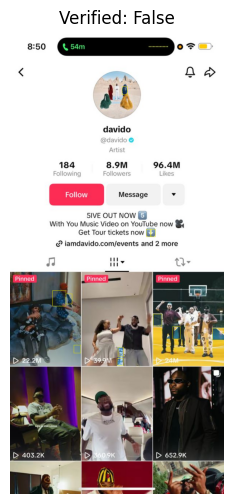

In [20]:

# Change these paths:
image_path = r"C:\Users\yemi\myratekard\veriry\WhatsApp Image 2025-10-13 at 8.51.21 PM.jpeg"   # e.g., "/content/sample.png"
templates_dir = None                          # e.g., "/content/templates" or leave as None

img = load_image(image_path)
is_verified, boxes, debug_img = detect_verified_badge(img, templates_dir=templates_dir,
                                                      debug_draw=True, score_thr=0.35)

print("Verified badge detected:", is_verified)
print("Boxes:", boxes)
show_bgr(debug_img, title=f"Verified: {is_verified}")


## 9) (Optional) Synthetic test — draw a fake badge

Verified badge detected (synthetic): False
Boxes: []


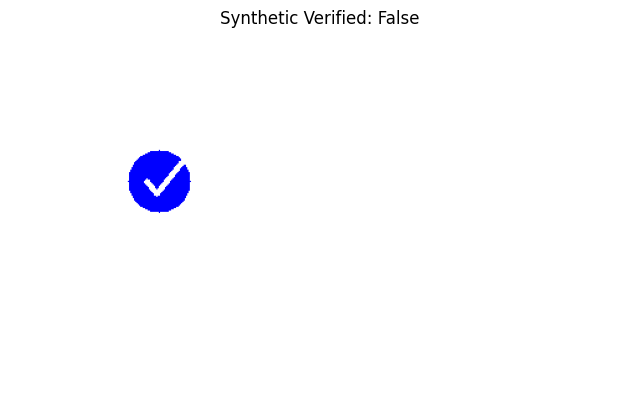

In [14]:

h, w = 300, 500
demo = np.zeros((h, w, 3), dtype=np.uint8) + 255

# Blue circle (BGR)
center = (120, 120); radius = 25
cv2.circle(demo, center, radius, (255, 0, 0), thickness=-1)

# White check
cv2.line(demo, (110,120), (118,130), (255,255,255), thickness=3)
cv2.line(demo, (118,130), (138,105), (255,255,255), thickness=3)

is_verified, boxes, debug_img = detect_verified_badge(demo, templates_dir=None, debug_draw=True)
print("Verified badge detected (synthetic):", is_verified)
print("Boxes:", boxes)
show_bgr(debug_img, title=f"Synthetic Verified: {is_verified}")



## 10) Tips and tuning

- **Small/Large screenshots**: adjust `min_diam_px` in `find_blue_badge_candidates` (e.g., 10 for tiny UI).
- **Stricter detection**: raise `score_thr` in `detect_verified_badge` to 0.45–0.55.
- **Dark-mode/grey badges**: add templates to `templates_dir` or widen HSV ranges to include grey.
- **Template prep**: crop tightly around the badge, keep transparent PNGs if possible, and include 2–5 variants (light/dark).
- **Batching**: wrap usage cell in a loop over a folder of images for mass checks.


Verified badge detected (synthetic): False


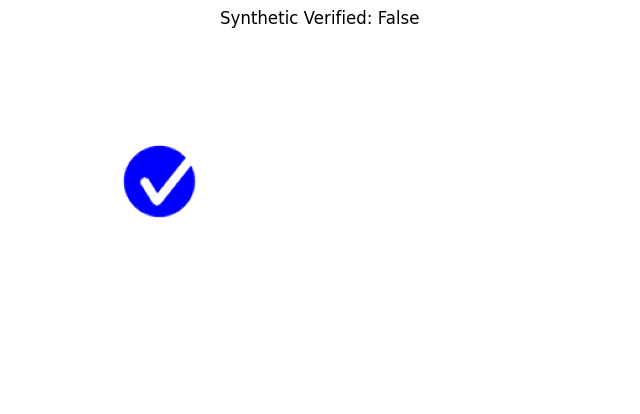

In [22]:
h, w = 300, 500
demo = np.full((h, w, 3), 255, np.uint8)

# Blue circle (BGR)
center = (120, 120); radius = 28
cv2.circle(demo, center, radius, (255, 0, 0), thickness=-1, lineType=cv2.LINE_AA)

# Thicker, AA white check ✓
cv2.line(demo, (108,120), (118,136), (255,255,255), thickness=5, lineType=cv2.LINE_AA)
cv2.line(demo, (118,136), (145,102), (255,255,255), thickness=5, lineType=cv2.LINE_AA)

is_verified, boxes, debug_img = detect_verified_badge(demo, templates_dir=None, debug_draw=True, score_thr=0.25)
print("Verified badge detected (synthetic):", is_verified)
show_bgr(debug_img, title=f"Synthetic Verified: {is_verified}")


In [23]:
# Inspect first candidate’s internals
cands = find_blue_badge_candidates(demo)
print("Candidates:", cands)

if cands:
    x1,y1,x2,y2 = cands[0]
    pad = int(0.15 * max((x2-x1), (y2-y1)))
    xa, ya = max(0, x1-pad), max(0, y1-pad)
    xb, yb = min(demo.shape[1]-1, x2+pad), min(demo.shape[0]-1, y2+pad)
    roi = demo[ya:yb, xa:xb]

    # Peek at white ratio and line count
    import cv2, numpy as np
    hsv = cv2.cvtColor(roi, cv2.COLOR_BGR2HSV)
    white = cv2.inRange(hsv, np.array([0,0,190]), np.array([179,80,255]))
    white_ratio = float(np.count_nonzero(white)) / (white.size + 1e-6)
    edges = cv2.Canny(cv2.equalizeHist(cv2.cvtColor(roi, cv2.COLOR_BGR2GRAY)), 40, 120)
    lines = cv2.HoughLinesP(edges, 1, np.pi/180, 18,
                            minLineLength=max(5, int(0.12*max(roi.shape[:2]))),
                            maxLineGap=int(0.20*max(roi.shape[:2])))

    print("white_ratio:", white_ratio, "lines_found:", 0 if lines is None else len(lines))
    show_bgr(roi, "ROI around candidate")
    plt.figure(figsize=(5,4)); plt.imshow(edges, cmap="gray"); plt.title("ROI edges"); plt.axis("off"); plt.show()


Candidates: []
